### Impoting important libraries 

In [1]:
import wbdata
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Define indicators we want ──
indicators = {
    'SP.DYN.TFRT.IN':  'fertility_rate',        # Fertility rate
    'NY.GDP.PCAP.CD':  'gdp_per_capita',         # GDP per capita (USD)
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth_rate',      # GDP growth rate %
    'SP.POP.TOTL':     'population',             # Total population
    'SL.UEM.TOTL.ZS':  'unemployment_rate',      # Unemployment %
    'SM.POP.NETM':     'net_migration',          # Net migration (target variable)
}

In [3]:
# ── Define date range ──
start_date = datetime(2000, 1, 1)
end_date   = datetime(2023, 1, 1)

In [8]:
# ── Pull all data ──
df = wbdata.get_dataframe(
    indicators,
    date=(start_date, end_date),
)

In [11]:
df[40:70]

fertility_rate  gdp_per_capita  \
country                    date                                   
Africa Western and Central 2007        5.809651     1405.880188   
                           2006        5.846028     1234.641856   
                           2005        5.871770      999.770023   
                           2004        5.895514      838.213392   
                           2003        5.923573      697.481256   
                           2002        5.956202      619.337335   
                           2001        5.990074      532.972787   
                           2000        6.022143      518.969226   
Arab World                 2023        3.089751     7513.899079   
                           2022        3.107767     7950.355820   
                           2021        3.145588     6697.414985   
                           2020        3.208269     5739.412836   
                           2019        3.255093     6674.342244   
                           2018        3.324269     6699.180582   
                           2017        3.425198     6096.723950   
                           2016        3.462988     6042.196754   
                           2015        3.532444     6290.558795   
                           2014        3.562126     7338.350927   
                           2013        3.574127     7376.028296   
                           2012        3.582160     7384.106828   
                           2011        3.565976     6915.827681   
                           2010        3.571861     5944.952173   
                           2009        3.571186     5134.450061   
                           2008        3.580285     6091.932064   
                           2007        3.604285     4940.702265   
                           2006        3.619228     4355.057569   
                           2005        3.643336     3750.698259   
                           2004        3.679651     3133.701879   
                           2003        3.727254     2696.672125   
                           2002        3.781001     2483.111875   

                                 gdp_growth_rate   population  \
country                    date                                 
Africa Western and Central 2007         5.447530  334984176.0   
                           2006         5.287171  325663158.0   
                           2005         5.797434  316588476.0   
                           2004         8.071473  307725100.0   
                           2003         5.626361  299142845.0   
                           2002         9.943307  290841795.0   
                           2001         5.248683  282780717.0   
                           2000         3.812161  274968446.0   
Arab World                 2023         1.634950  482105978.0   
                           2022         7.007759  471352066.0   
                           2021         4.431609  460646603.0   
                           2020        -5.301028  453723239.0   
                           2019         1.747781  444281315.0   
                           2018         2.672553  435998060.0   
                           2017         1.329010  428315886.0   
                           2016         3.572868  419808341.0   
                           2015         3.350804  410190679.0   
                           2014         2.659752  400231008.0   
                           2013         2.647321  390954281.0   
                           2012         5.493754  381030177.0   
                           2011         3.853204  372054934.0   
                           2010         4.840642  363568534.0   
                           2009         0.648247  356386673.0   
                           2008         5.571160  347684619.0   
                           2007         4.601165  338947976.0   
                           2006         6.276297  330526310.0   
                           2005         5.572955  322628451.0   
   

In [12]:
# ── Reset index ──
df = df.reset_index()
df.columns = ['country', 'date'] + list(df.columns[2:])

In [13]:
df[40:70]

,country,date,fertility_rate,gdp_per_capita,gdp_growth_rate,population,unemployment_rate,net_migration
40,Africa Western and Central,2007,5.809651,1405.880188,5.447530,334984176.0,3.948058,-217242.0
41,Africa Western and Central,2006,5.846028,1234.641856,5.287171,325663158.0,3.969279,-213837.0
42,Africa Western and Central,2005,5.871770,999.770023,5.797434,316588476.0,4.096465,-127048.0
43,Africa Western and Central,2004,5.895514,838.213392,8.071473,307725100.0,4.086891,-15775.0
44,Africa Western and Central,2003,5.923573,697.481256,5.626361,299142845.0,4.167979,-72858.0
45,Africa Western and Central,2002,5.956202,619.337335,9.943307,290841795.0,4.273706,4172.0
46,Africa Western and Central,2001,5.990074,532.972787,5.248683,282780717.0,4.465196,1062.0
47,Africa Western and Central,2000,6.022143,518.969226,3.812161,274968446.0,4.530843,29309.0
48,Arab World,2023,3.089751,7513.899079,1.634950,482105978.0,9.313389,482824.0
49,Arab World,2022,3.107767,7950.355820,7.007759,471352066.0,9.744131,2684826.0


### Clean and filter countries 

In [14]:
# ── Define our origin and destination countries ──
destination_countries = [
    'United Kingdom',
    'United States',
    'Germany',
    'France',
    'Canada'
]

In [15]:
# ── Major origin regions ──
origin_countries = [
    # South Asia
    'Pakistan', 'India', 'Bangladesh', 'Nepal', 'Sri Lanka',
    # Middle East
    'Syria', 'Iraq', 'Afghanistan', 'Yemen', 'Iran',
    # Sub Saharan Africa
    'Nigeria', 'Ethiopia', 'Somalia', 'Ghana', 'Kenya',
    'Tanzania', 'Uganda', 'Mozambique', 'Sudan',
    # North Africa
    'Morocco', 'Algeria', 'Tunisia', 'Egypt', 'Libya',
    # Eastern Europe
    'Poland', 'Romania', 'Ukraine', 'Bulgaria',
    # Latin America
    'Mexico', 'Guatemala', 'Honduras', 'El Salvador',
    'Venezuela', 'Colombia', 'Brazil'
]

In [16]:
all_countries = destination_countries + origin_countries

In [17]:
df_filtered = df[df['country'].isin(all_countries)].copy()
df_filtered['date'] = pd.to_datetime(df_filtered['date']).dt.year

In [18]:
df_filtered

,country,date,fertility_rate,gdp_per_capita,gdp_growth_rate,population,unemployment_rate,net_migration
1176,Afghanistan,2023,4.8400,413.757895,2.266944,41454761.0,14.008,-48958.0
1177,Afghanistan,2022,4.9320,357.261153,-6.240172,40578842.0,14.100,-647402.0
1178,Afghanistan,2021,5.0390,356.496214,-20.738839,40000412.0,12.006,-548784.0
1179,Afghanistan,2020,5.1450,510.787063,-2.351101,39068979.0,11.710,143634.0
1180,Afghanistan,2019,5.2380,496.602504,3.911603,37856121.0,11.187,9159.0
...,...,...,...,...,...,...,...,...
6139,United States,2004,2.0515,41724.631629,3.847772,292805298.0,5.529,1313467.0
6140,United States,2003,2.0475,39490.274956,2.795606,290107933.0,5.989,1331376.0
6141,United States,2002,2.0205,37997.759657,1.700447,287625193.0,5.783,1336518.0
6142,United States,2001,2.0305,37133.623113,0.955538,284968955.0,4.731,1312455.0


In [19]:
print(df_filtered.isnull().sum())

country              0
date                 0
fertility_rate       0
gdp_per_capita       0
gdp_growth_rate      1
population           0
unemployment_rate    3
net_migration        0
dtype: int64


In [20]:
print((df_filtered.isnull().sum() / len(df_filtered) * 100).round(1))

country              0.0
date                 0.0
fertility_rate       0.0
gdp_per_capita       0.0
gdp_growth_rate      0.1
population           0.0
unemployment_rate    0.4
net_migration        0.0
dtype: float64


In [21]:
df_filtered = df_filtered.sort_values(['country', 'date'])
df_filtered = df_filtered.groupby('country').apply(
    lambda x: x.fillna(method='ffill').fillna(method='bfill')
).reset_index(drop=True)

In [22]:
print(f"\nAfter filling:")
print(df_filtered.isnull().sum())


After filling:
country              0
date                 0
fertility_rate       0
gdp_per_capita       0
gdp_growth_rate      0
population           0
unemployment_rate    0
net_migration        0
dtype: int64


In [23]:
# ── Add destination GDP for gap calculation ──
dest_gdp = df_filtered[
    df_filtered['country'].isin(destination_countries)
][['date', 'country', 'gdp_per_capita']].copy()

In [25]:
dest_gdp

,date,country,gdp_per_capita
120,2000,Canada,24271.002056
121,2001,Canada,23822.096211
122,2002,Canada,24256.019234
123,2003,Canada,28301.864594
124,2004,Canada,32145.541262
...,...,...,...
811,2019,United States,64746.450678
812,2020,United States,63515.949181
813,2021,United States,70205.050916
814,2022,United States,76657.248884


In [26]:
# Average GDP of all 5 destination countries per year
avg_dest_gdp = dest_gdp.groupby('date')['gdp_per_capita'].mean().reset_index()
avg_dest_gdp.columns = ['date', 'avg_dest_gdp']

In [27]:
# Merge back
df_filtered = df_filtered.merge(avg_dest_gdp, on='date', how='left')

In [28]:
# ── GDP Gap Ratio — strongest predictor ──
df_filtered['gdp_gap_ratio'] = (
    df_filtered['avg_dest_gdp'] / df_filtered['gdp_per_capita']
)

In [29]:
# ── Fertility pressure index ──
# High fertility + low GDP = high migration pressure
df_filtered['migration_pressure'] = (
    df_filtered['fertility_rate'] * df_filtered['gdp_gap_ratio']
)

In [30]:
# ── Population growth rate ──
df_filtered['pop_growth'] = df_filtered.groupby('country')['population'].pct_change() * 100

# ── Lag features — GDP 5 years ago predicts migration today ──
df_filtered['gdp_lag_5'] = df_filtered.groupby('country')['gdp_per_capita'].shift(5)
df_filtered['fertility_lag_3'] = df_filtered.groupby('country')['fertility_rate'].shift(3)

print("✅ Features engineered!")
print(f"\nNew columns added:")
print(['gdp_gap_ratio', 'migration_pressure', 'pop_growth', 'gdp_lag_5', 'fertility_lag_3'])

✅ Features engineered!

New columns added:
['gdp_gap_ratio', 'migration_pressure', 'pop_growth', 'gdp_lag_5', 'fertility_lag_3']


In [32]:
df_filtered.to_csv('data/master_migration_dataset.csv', index=False)

print("✅ Master dataset saved!")
print(f"\nFinal shape: {df_filtered.shape}")
print(f"\nColumns: {df_filtered.columns.tolist()}")
print(f"\nSample data:")
print(df_filtered[df_filtered['country'] == 'Pakistan'].tail(5))

✅ Master dataset saved!

Final shape: (816, 14)

Columns: ['country', 'date', 'fertility_rate', 'gdp_per_capita', 'gdp_growth_rate', 'population', 'unemployment_rate', 'net_migration', 'avg_dest_gdp', 'gdp_gap_ratio', 'migration_pressure', 'pop_growth', 'gdp_lag_5', 'fertility_lag_3']

Sample data:
      country  date  fertility_rate  gdp_per_capita  gdp_growth_rate  \
571  Pakistan  2019           3.810     1390.416910         2.497637   
572  Pakistan  2020           3.765     1278.397352        -1.274087   
573  Pakistan  2021           3.720     1455.319224         6.513886   
574  Pakistan  2022           3.662     1538.322813         4.778107   
575  Pakistan  2023           3.605     1360.324178        -0.414936   

      population  unemployment_rate  net_migration  avg_dest_gdp  \
571  230800899.0              4.830     -1177220.0  48464.509149   
572  235001746.0              5.994      -559291.0  46886.240399   
573  239477801.0              6.338      -565673.0  53371.48707

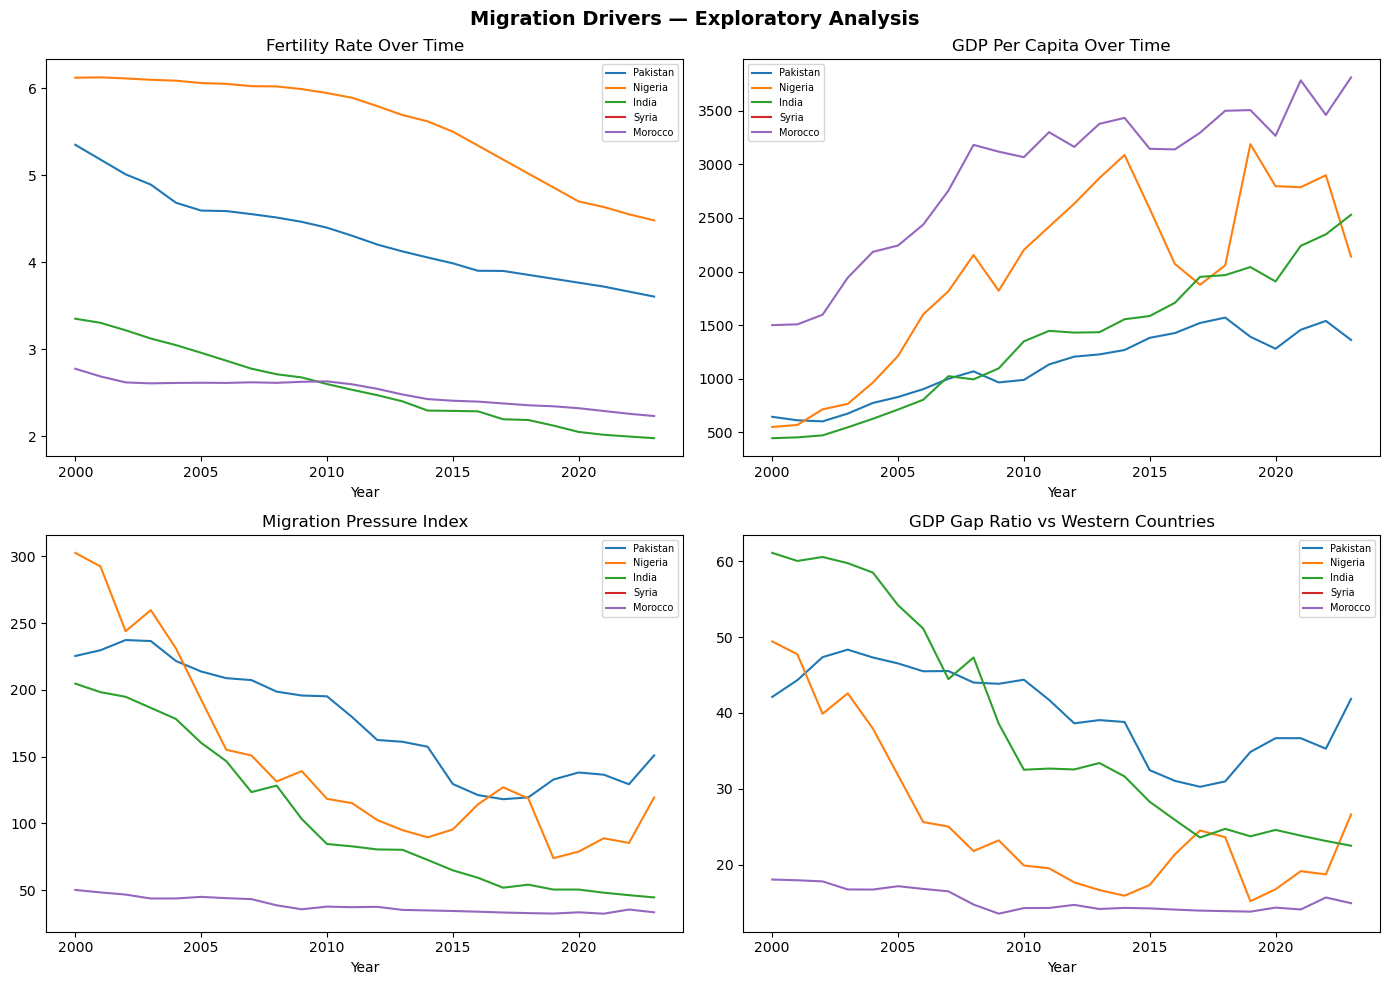

✅ EDA plots saved!


In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Fertility rate over time for top origin countries
countries_to_plot = ['Pakistan', 'Nigeria', 'India', 'Syria', 'Morocco']
for country in countries_to_plot:
    data = df_filtered[df_filtered['country'] == country]
    axes[0,0].plot(data['date'], data['fertility_rate'], label=country)
axes[0,0].set_title('Fertility Rate Over Time')
axes[0,0].set_xlabel('Year')
axes[0,0].legend(fontsize=7)

# Plot 2 — GDP per capita over time
for country in countries_to_plot:
    data = df_filtered[df_filtered['country'] == country]
    axes[0,1].plot(data['date'], data['gdp_per_capita'], label=country)
axes[0,1].set_title('GDP Per Capita Over Time')
axes[0,1].set_xlabel('Year')
axes[0,1].legend(fontsize=7)

# Plot 3 — Migration pressure index
for country in countries_to_plot:
    data = df_filtered[df_filtered['country'] == country]
    axes[1,0].plot(data['date'], data['migration_pressure'], label=country)
axes[1,0].set_title('Migration Pressure Index')
axes[1,0].set_xlabel('Year')
axes[1,0].legend(fontsize=7)

# Plot 4 — GDP gap ratio
for country in countries_to_plot:
    data = df_filtered[df_filtered['country'] == country]
    axes[1,1].plot(data['date'], data['gdp_gap_ratio'], label=country)
axes[1,1].set_title('GDP Gap Ratio vs Western Countries')
axes[1,1].set_xlabel('Year')
axes[1,1].legend(fontsize=7)

plt.suptitle('Migration Drivers — Exploratory Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/migration_eda.png', dpi=150)
plt.show()

print("✅ EDA plots saved!")